<center>

# **EARLY SEPSIS DETECTION IN INTENSIVE CARE UNIT PATIENTS USING MACHINE LEARNING**

# **Name:** Florentine Mukamana

## **Context:** Decision Support Systems for Critical Care

</center>

## **Introduction**
Sepsis is a life‑threatening condition and a leading cause of Intensive Care Unit (ICU) mortality worldwide, including in many under‑resourced African hospitals where staff shortages make continuous monitoring difficult. Early recognition is vital, as delayed treatment sharply increases the risk of organ failure and death.

Intensive Care Unit (ICU) monitors generate large volumes of data, yet early sepsis signals are subtle and hard to interpret in real time. This study explores machine‑learning approaches for early sepsis risk prediction, using clinically informed evaluation and recall‑focused metrics. The work investigates whether such models could eventually support over‑burdened clinicians as an early‑warning decision‑assistance tool, not an automated diagnosis.

## **Problem Statement and Motivation**
Early detection of sepsis is challenging due to subtle physiological changes, severe class imbalance, complex ICU data, and time‑critical decision‑making. Clinicians must monitor many patients simultaneously, increasing the risk that early sepsis indicators are missed.

This project is motivated by the need to evaluate whether machine learning models can meaningfully support early‑warning risk stratification when assessed using recall‑focused metrics and calibrated probability estimates.

## **Project ojectives:**
**Main objective:** o develop and evaluate a machine‑learning‑based early‑warning system for predicting sepsis risk in ICU patients using real clinical data.

**Specific objectives:**
1. To identify clinically relevant predictors of sepsis using real ICU patient data.
2. To train and compare different models on a highly imbalanced sepsis dataset.
3. To evaluate model performance using ROC‑AUC and other clinically relevant metrics.
4. To assess the suitability of the selected model as an early‑warning decision support system, emphasizing safe risk stratification rather than automated diagnosis.




## **Dataset Description and Scope Clarification**

The dataset is derived from the PhysioNet/Computing in Cardiology 2019 Sepsis Challenge. It consists of hourly ICU measurements recorded for individual patients, with multiple observations per patient. The binary target, SepsisLabel, marks whether an observation falls within a six-hour window before clinical sepsis recognition.

All variables are numeric and capture vital signs, laboratory results, and demographic information. Vital signs include heart rate (HR), respiratory rate (Resp), temperature (Temp), systolic blood pressure (SBP), diastolic blood pressure (DBP), mean arterial pressure (MAP), and oxygen saturation (O2Sat). Elevated HR and respiratory rate, abnormal temperature, low blood pressure, and reduced O2Sat serve as early physiological indicators of sepsis.

Laboratory measurements consist of white blood cell count (WBC), blood urea nitrogen (BUN), glucose, pH, the electrolytes potassium, magnesium, and phosphate, haemoglobin (Hgb), haematocrit (Hct), and partial thromboplastin time (PTT). These variables reflect infection, organ function, metabolic stress, and coagulation status.

Demographic features are age in years and gender as a binary variable, which help contextualise the physiological data.

The dataset is characterised by irregular and incomplete measurements, a severe class imbalance with rare sepsis cases, and the variability of real clinical practice.



In this study, each ICU observation is treated as an independent sample. Patient identifiers and explicit temporal structure are not modeled. Consequently, reported performance metrics should be interpreted as illustrative of model behaviour rather than patient‑level generalization suitable for deployment.


## 1. **Importing necessary libraries**
The following libraries are imported to support data manipulation, visualisation, machine learning modeling, and model evaluation.
Warnings are suppressed to keep outputs clean and focused.

In [1]:
# from markdown import Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import pickle
import warnings
warnings.filterwarnings("ignore")


## 2.  **Load and Inspect**

**Dataset link on my github account :** https://raw.githubusercontent.com/Mflorentine/Florentine_Mukamana_Rwanda_FinalProject/refs/heads/main/sepsis_dataset.csv

In [2]:
# Load the ICU sepsis dataset directly from my GitHub repository
url = 'https://raw.githubusercontent.com/Mflorentine/Florentine_Mukamana_Rwanda_FinalProject/refs/heads/main/sepsis_dataset.csv'
data = pd.read_csv(url)

# Drop unnamed index column
data = data.drop(columns=["Unnamed: 0"], errors="ignore")

print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
data.head()

Rows: 546123, Columns: 20


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,pH,BUN,Glucose,Magnesium,Phosphate,Potassium,Hct,Hgb,PTT,WBC,Age,Gender,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0.0,0.0
1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0.0,0.0
2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0.0,0.0
3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0.0,0.0
4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,23.0,161.0,1.6,2.1,3.2,29.7,9.5,30.6,11.3,68.54,0.0,0.0


## 3.  **Initial data inspection**



Understanding the feature types, degree of missingness, and overall structure of the dataset.

In [3]:
data.info()
# Column names
print(data.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546123 entries, 0 to 546122
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   HR           504000 non-null  float64
 1   O2Sat        480319 non-null  float64
 2   Temp         184511 non-null  float64
 3   SBP          462920 non-null  float64
 4   MAP          490527 non-null  float64
 5   DBP          284671 non-null  float64
 6   Resp         492675 non-null  float64
 7   pH           62185 non-null   float64
 8   BUN          44450 non-null   float64
 9   Glucose      66308 non-null   float64
 10  Magnesium    42391 non-null   float64
 11  Phosphate    27606 non-null   float64
 12  Potassium    59009 non-null   float64
 13  Hct          64279 non-null   float64
 14  Hgb          48068 non-null   float64
 15  PTT          26439 non-null   float64
 16  WBC          40929 non-null   float64
 17  Age          546122 non-null  float64
 18  Gender       546122 non-

In [4]:
#Check data types and
print('Data types summary:')
print(data.dtypes)

Data types summary:
HR             float64
O2Sat          float64
Temp           float64
SBP            float64
MAP            float64
DBP            float64
Resp           float64
pH             float64
BUN            float64
Glucose        float64
Magnesium      float64
Phosphate      float64
Potassium      float64
Hct            float64
Hgb            float64
PTT            float64
WBC            float64
Age            float64
Gender         float64
SepsisLabel    float64
dtype: object


In [5]:
# Missingness overview
data.isna().sum().sort_values(ascending=False)

,0
PTT,519684
Phosphate,518517
WBC,505194
Magnesium,503732
BUN,501673
Hgb,498055
Potassium,487114
pH,483938
Hct,481844
Glucose,479815


The dataset exhibits substantial missingness, which is typical of ICU data because measurements are taken at irregular intervals based on clinical need.

## 4. **Target variable analysis**

Sepsis is a rare but critical event.
A model that predicts “no sepsis” for everyone would appear accurate but would be clinically useless.
Therefore:

- Class imbalance is explicitly examined
- Accuracy is avoided as a primary metric
- Recall and ROC‑AUC are prioritized

No Sepsis (0): 534,272 (97.8%)
Sepsis (1):    11,850 (2.2%)
Imbalance ratio: 45.1 : 1


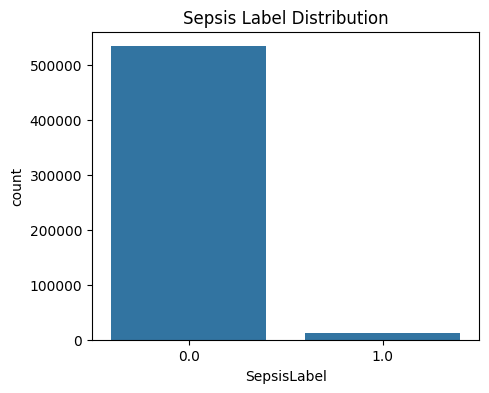

In [6]:
target = "SepsisLabel"
counts = data[target].value_counts()
print(f"No Sepsis (0): {counts[0]:,} ({counts[0]/len(data)*100:.1f}%)")
print(f"Sepsis (1):    {counts[1]:,} ({counts[1]/len(data)*100:.1f}%)")
print("Imbalance ratio:", round(counts[0] / counts[1], 1), ": 1")

plt.figure(figsize=(5,4))
sns.countplot(x=target, data=data)
plt.title("Sepsis Label Distribution")
plt.show()


The dataset is severely imbalanced: 534,272 observations (97.8 %) belong to the non‑sepsis class and 11,850 (2.2 %) to the sepsis class.

Because sepsis cases are rare, accuracy is a misleading metric. Instead, this work prioritises ROC‑AUC and recall.

## 5. **Data Preprocessing**

Intensive Care Unit (ICU) data contains missing values due to irregular measurement schedules.
Rather than dropping rows, median imputation is used because:

- It is robust to outliers
- It preserves clinical distributions

Duplicate rows are also removed to avoid bias.

In [7]:
# Identify numeric columns (all features in this dataset are numeric)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Median imputation is preferred for ICU data for robustnes to extreme physiological values and for preservation of  population-level distribution
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Check if missing values removed
print("Total missing values after imputation:", data.isnull().sum().sum())

Total missing values after imputation: 0


In [8]:
# Check for duplicate rows in the dataset
duplicate_count = data.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    # Remove duplicate rows to avoid bias in model training
    data = data.drop_duplicates()
    print(f"Duplicates removed. New shape: {data.shape}")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 28103
Duplicates removed. New shape: (518020, 20)


## 6. **Feature Selection**
Feature selection balances:

- Statistical relevance
- Clinical importance
- Model simplicity

Correlation with the target is used as an initial filter, while `Age` and `Gender` are retained due to their clinical relevance.

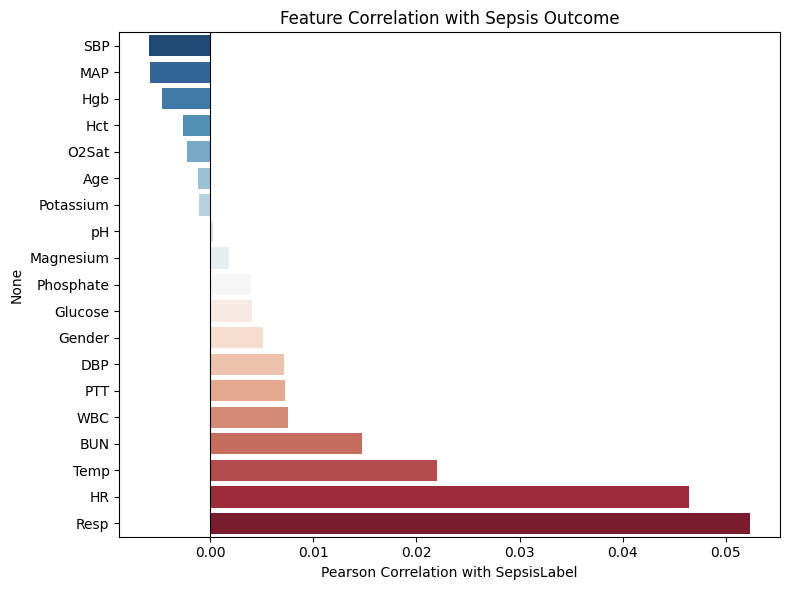

In [9]:
# Compute correlation of all features with the target
corr_with_target = (data[numeric_cols].corr()['SepsisLabel'].drop('SepsisLabel').sort_values())
plt.figure(figsize=(8, 6))
sns.barplot( x=corr_with_target.values,y=corr_with_target.index,palette='RdBu_r')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with SepsisLabel')
plt.title('Feature Correlation with Sepsis Outcome')
plt.tight_layout()
plt.show()

This plot shows that:
- Respiratory rate, heart rate, temperature, white blood cell count, and blood urea nitrogen have the strongest positive correlations with sepsis, reflecting well‑known clinical manifestations of infection and organ stress.

- Blood pressure measures (SBP, MAP), oxygen saturation, hemoglobin, and hematocrit are negatively correlated with sepsis, consistent with hypotension, hypoxia, and hematologic changes commonly observed in septic patients.

- While many features show weak linear correlations, this analysis confirms clinical plausibility of the data; complex, non‑linear relationships are later captured more effectively by tree‑based models such as Random Forest and Gradient Boosting.


In [10]:
# Compute absolute Pearson correlation with the target
feature_cols = [col for col in numeric_cols if col != 'SepsisLabel']

correlations = (data[feature_cols] .corrwith(data['SepsisLabel']).abs().sort_values(ascending=False))

top10_features = correlations.drop(['Age', 'Gender'], errors='ignore').head(10).index.tolist()

final_features = []
if 'Age' in data.columns:
    final_features.append('Age')
if 'Gender' in data.columns:
    final_features.append('Gender')

final_features.extend(f for f in top10_features if f not in final_features)

print("Final selected features:")
for i, f in enumerate(final_features, 1):
    print(f"  {i:2}. {f}")

Final selected features:
   1. Age
   2. Gender
   3. Resp
   4. HR
   5. Temp
   6. BUN
   7. WBC
   8. PTT
   9. DBP
  10. SBP
  11. MAP
  12. Hgb


Exploratory feature selection was conducted using the absolute Pearson correlation between each clinical variable and the target outcome (`SepsisLabel`). All numerical features except the target were considered, and the Pearson correlation coefficient was computed for each. The absolute value was taken because both positive and negative associations can contribute predictive information. Features were ranked in descending order of correlation strength, and the ten most strongly correlated variables were retained.

Demographic variables (Age and Gender) were deliberately included regardless of their correlation rank, owing to their clinical relevance and contribution to model generalisation and fairness. The final feature set therefore balances statistical relevance, clinical importance, and model interpretability. Pearson correlation captures only linear relationships; complex interactions and temporal effects are addressed later by the machine learning models.

## 7. **Data splitting into training and testing set**

In [11]:
# Define features / predictors / independent variables X and target variable / dependent variable y
# X contains selected clinical features
# y is the binary sepsis outcome
X = data[final_features]
y = data['SepsisLabel']
print("Feature matrix shape:", X.shape)
print("Target vector shape :", y.shape)


Feature matrix shape: (518020, 12)
Target vector shape : (518020,)


In [12]:
# Split the data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples: {X_train.shape}")
print(f"Testing samples : {X_test.shape}")
print(f"Sepsis rate (train): {y_train.mean():.4f}")
print(f"Sepsis rate (test) : {y_test.mean():.4f}")


Training samples: (414416, 12)
Testing samples : (103604, 12)
Sepsis rate (train): 0.0223
Sepsis rate (test) : 0.0223


The data is split into training and testing sets using an 80/20 ratio while preserving sepsis prevalence.
This simulates real clinical deployment where future patients are unseen.

## **8. Model Training and Evaluation**

Train multiple machine learning models on the prepared ICU dataset and evaluate their performance using metrics suitable for highly imbalanced clinical outcomes.

Three models are compared: Logistic Regression, Random Forest, and Gradient Boosting. All models handle class imbalance via `class_weight='balanced'`, except Gradient Boosting, which does not require an explicit class‑weight parameter.

In [13]:
# Initialize models
log_reg = LogisticRegression(class_weight="balanced", max_iter=500)
rf = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "Gradient Boosting": gb
}


Three models are trained to compare performance across different levels of complexity.

Model: Logistic Regression
Model: Logistic Regression
              precision    recall  f1-score   support

   No Sepsis       0.98      0.63      0.77    101291
      Sepsis       0.03      0.57      0.06      2313

    accuracy                           0.63    103604
   macro avg       0.51      0.60      0.42    103604
weighted avg       0.96      0.63      0.75    103604

ROC-AUC Score: 0.6343



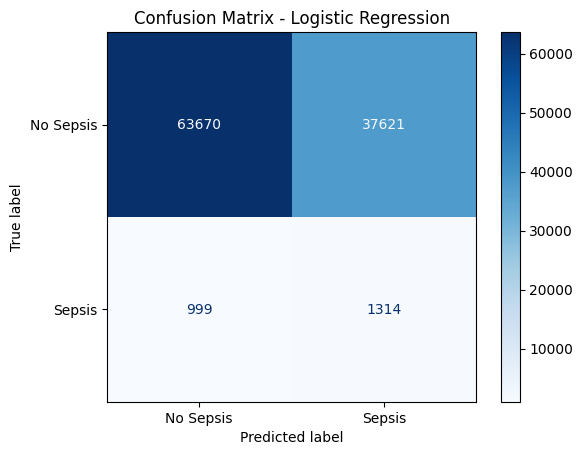

Model: Random Forest
Model: Random Forest
              precision    recall  f1-score   support

   No Sepsis       0.98      1.00      0.99    101291
      Sepsis       0.18      0.01      0.02      2313

    accuracy                           0.98    103604
   macro avg       0.58      0.50      0.50    103604
weighted avg       0.96      0.98      0.97    103604

ROC-AUC Score: 0.7903



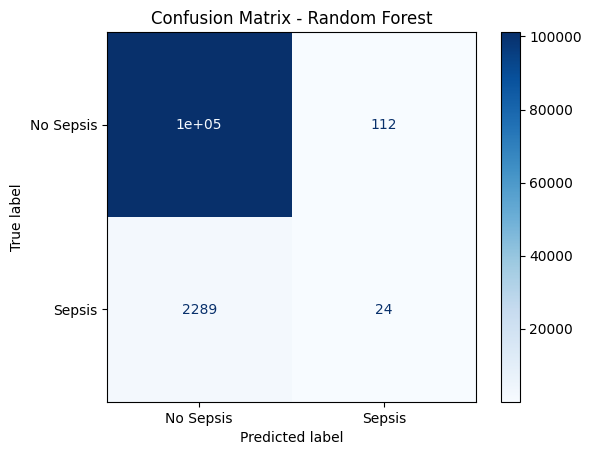

Model: Gradient Boosting
Model: Gradient Boosting
              precision    recall  f1-score   support

   No Sepsis       0.98      1.00      0.99    101291
      Sepsis       0.33      0.00      0.00      2313

    accuracy                           0.98    103604
   macro avg       0.66      0.50      0.50    103604
weighted avg       0.96      0.98      0.97    103604

ROC-AUC Score: 0.6793



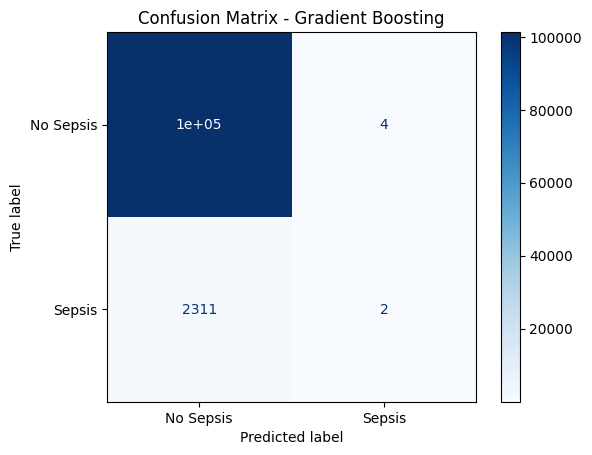

In [14]:
# Store evaluation results
results = {}
for name, model in models.items():
# Train
  model.fit(X_train, y_train)
  print(f"Model: {name}")

# Predict
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
  auc = roc_auc_score(y_test, y_proba)
  results[name] = {"model": model,"auc": auc,"y_pred": y_pred}
  print(f"Model: {name}")
  print(classification_report(y_test,y_pred,target_names=["No Sepsis", "Sepsis"]))
  print(f"ROC-AUC Score: {auc:.4f}\n")

  # Confusion matrix
  ConfusionMatrixDisplay.from_estimator(model,X_test,y_test,display_labels=["No Sepsis", "Sepsis"],cmap="Blues"
    )
  plt.title(f"Confusion Matrix - {name}")
  plt.show()


Among the evaluated models, Logistic Regression achieves the highest sensitivity for sepsis detection, while Random Forest and Gradient Boosting achieve higher overall discrimination but fail to detect septic patients at the default classification threshold, making them unsuitable for direct clinical use without calibration.



In [15]:
print("\nModel ROC‑AUC comparison:")
for name, res in results.items():
    print(f"  {name:20} : {res['auc']:.4f}")

best_name = max(results, key=lambda x: results[x]['auc'])
print(f"\n Best model: {best_name} (AUC = {results[best_name]['auc']:.4f})")


Model ROC‑AUC comparison:
  Logistic Regression  : 0.6343
  Random Forest        : 0.7903
  Gradient Boosting    : 0.6793

 Best model: Random Forest (AUC = 0.7903)


Although Random Forest achieved the highest ROC‑AUC, Logistic Regression demonstrated higher sensitivity and is therefore more suitable for early sepsis warning, where minimising false negatives is critical. To ensure reliable risk estimates, both models were subsequently calibrated.

Probability calibration was applied to Logistic Regression and Random Forest, the two models with clinical relevance. Logistic Regression was calibrated to improve risk estimates under severe class imbalance; Random Forest was calibrated to translate its high discriminative power into clinically useful probabilities. Gradient Boosting was excluded from calibration because it failed to detect sepsis cases at the default threshold.

## 9. **Probability Calibration**

In highly imbalanced clinical data, raw model probabilities are often unreliable.
A model may rank patients well (high ROC‑AUC) while still producing probabilities that are too conservative for safe clinical use.

Probability calibration transforms raw model outputs into clinically meaningful risk estimates, which is essential for threshold selection and deployment.

### Calibrate Logistic Regression and Random Forest

In [16]:
calibrated_lr = CalibratedClassifierCV(
    estimator=log_reg,
    method="sigmoid",
    cv=5
)

calibrated_rf = CalibratedClassifierCV(
    estimator=rf,
    method="sigmoid",
    cv=5
)

calibrated_lr.fit(X_train, y_train)
calibrated_rf.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        n_estimators=200,
                                                        random_state=42))

Compare predicted probabilities with observed sepsis frequencies using Calibration curves

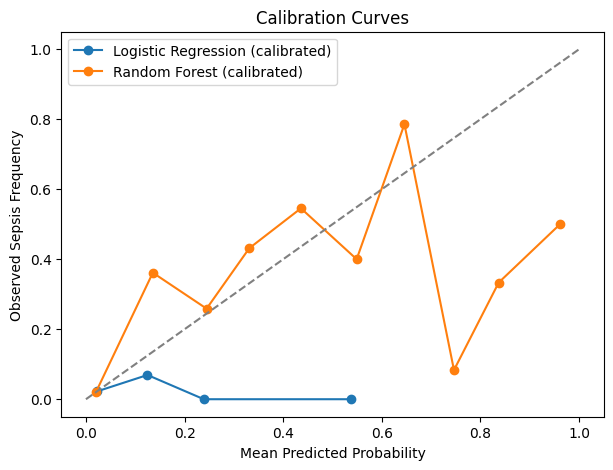

In [17]:
lr_probs = calibrated_lr.predict_proba(X_test)[:, 1]
rf_probs = calibrated_rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7,5))

for name, probs in {
    "Logistic Regression (calibrated)": lr_probs,
    "Random Forest (calibrated)": rf_probs
}.items():
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Sepsis Frequency")
plt.title("Calibration Curves")
plt.legend()
plt.show()

This figure shows the calibration curves for two calibrated models that Logistic Regression shown with blue curve and Random Forest shown orange curve.

The x‑axis represents the mean predicted probability of sepsis, and the y‑axis represents the observed frequency of sepsis.
The diagonal dashed line represents perfect calibration, where predicted risk exactly matches observed outcomes.

The curve of Logistic Regression lies well below the diagonal, especially at moderate predicted probabilities. This indicates that Logistic Regression systematically underestimates sepsis risk For example, when the model predicts a probability around 0.2–0.5, the observed sepsis frequency is close to zero. Even after calibration, the model remains conservative in its probability estimate.

The Random Forest curve fluctuates around the diagonal.
In several regions (around 0.3–0.6), the curve is closer to the ideal calibration line than Logistic Regression.
At higher predicted probabilities, the curve becomes unstable due to few data points in high‑risk bins and the rarity of sepsis cases.

Calibration improves both models, but `Random Forest` performs more, as it converts ranking ability (high ROC‑AUC) into clinically meaningful risk probabilities.

## 10. **Save the best Model**

In [18]:
final_model = calibrated_rf
final_model_name = "RandomForest"
with open("final_sepsis_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print(f"Final deployed model saved: {final_model_name}")


Final deployed model saved: RandomForest


After probability calibration and clinically informed evaluation, the Random Forest model was selected as the final model based on its superior discriminative performance (ROC‑AUC = 0.79) and improved reliability of predicted risk scores. The calibrated model is saved to ensure reproducibility and is **ready to be deployed as an early‑warning decision support system**, providing risk‑based sepsis predictions rather than automated diagnosis.

## **Conclusion**

This project demonstrates that machine learning can support early sepsis risk prediction in Intensive Care Unit (ICU) patients when evaluated using clinically meaningful approaches. The comparative analysis showed that Random Forest achieved the highest discriminative performance (ROC‑AUC = 0.79), followed by Gradient Boosting (ROC‑AUC = 0.68) and Logistic Regression (ROC‑AUC = 0.63).

However, results also revealed that high ROC‑AUC alone is insufficient in highly imbalanced clinical data, as some models failed to reliably identify septic patients at default decision thresholds. By prioritizing recall, analyzing confusion matrices, and applying probability calibration, this work emphasizes the importance of clinical safety and reliable risk estimation over traditional performance metrics.

 The main objective was achieved by combining clinically informed evaluation, probability calibration, and recall‑focused analysis to demonstrate how machine learning can support early sepsis risk detection in ICU patients as a decision‑support tool rather than an automated diagnostic system.

 In future work, this research aims to incorporate explainable machine learning techniques to help clinicians understand why a patient is predicted to be at risk of sepsis.